In [15]:
"""
Research-Grade ECG Sleep Apnea Classification Pipeline
======================================================
This script is designed to be run in Google Colab or locally.
Upload to Colab, change runtime to GPU, and run all cells.

Sections:
1. Setup & Installation
2. Data Download & Exploration
3. Configuration
4. Model Definition
5. 5-Fold Cross-Validation Training
6. Results & Visualizations
"""

'\nResearch-Grade ECG Sleep Apnea Classification Pipeline\n======================================================\nThis script is designed to be run in Google Colab or locally.\nUpload to Colab, change runtime to GPU, and run all cells.\n\nSections:\n1. Setup & Installation\n2. Data Download & Exploration\n3. Configuration\n4. Model Definition\n5. 5-Fold Cross-Validation Training\n6. Results & Visualizations\n'

# 🫀 Research-Grade ECG Sleep Apnea Classification
**Dataset:** PhysioNet Apnea-ECG Database
**Task:** Binary per-minute classification (Normal vs Apnea)
**Method:** 5-Fold Cross-Validation with FLOPs, Early Stopping, Checkpoints

## 1. Setup & Installation

In [16]:
# === CELL 1: Install Dependencies ===
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

install("wfdb")
install("torch")
install("torchvision")
install("scikit-learn")
install("matplotlib")
install("seaborn")
install("tqdm")
install("pandas")
install("scipy")

try:
    import google.colab
    IN_COLAB = True
    print("✓ Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("✓ Running locally")

✓ Running in Google Colab


In [17]:
# === CELL 2: Imports ===
import os, gc, json, csv, copy, time, random, warnings
from pathlib import Path
from typing import Optional, Dict, List, Tuple, Any, Callable
from dataclasses import dataclass, field, asdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report,
)

import wfdb
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy.ndimage import zoom as scipy_zoom
from scipy.signal import butter, filtfilt

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ PyTorch {torch.__version__} | Device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

✓ PyTorch 2.10.0+cu128 | Device: cuda
  GPU: Tesla T4


## 2. Data Download & Exploration

In [18]:
# === CELL 3: Download Apnea-ECG Database ===
# Search for data in common locations
possible_paths = [
    Path("data/apnea-ecg-database-1.0.0"),          # Local root
    Path("../data/apnea-ecg-database-1.0.0"),       # From notebooks/
    Path("/content/apnea-ecg-database-1.0.0"),      # Colab root
    Path("/content/EEG/data/apnea-ecg-database-1.0.0") # Colab if cloned
]

# Default path if not found
DATA_DIR = Path("data/apnea-ecg-database-1.0.0")

for p in possible_paths:
    if p.exists() and any(p.glob("*.hea")):
        DATA_DIR = p
        print(f"✓ Data found at: {DATA_DIR.absolute()}")
        break
else:
    # If loop completes without break, data was not found
    print(f"Dataset not found or incomplete. Downloading to {DATA_DIR.absolute()}...")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    # This downloads ~500MB and can take 10-20 mins depending on PhysioNet
    wfdb.dl_database('apnea-ecg', str(DATA_DIR))
    print("✓ Download complete!")

# List available records
hea_files = sorted(DATA_DIR.glob("*.hea"))
record_names = [f.stem for f in hea_files if not f.stem.endswith(('er', 'r'))]
print(f"  Found {len(record_names)} records: {record_names[:5]}...")

✓ Data found at: /content/data/apnea-ecg-database-1.0.0
  Found 42 records: ['a01', 'a02', 'a03', 'a04', 'a05']...



📊 Training Set Distribution:
  Normal minutes: 10531
  Apnea minutes:  6514
  Total:          17045
  Apnea ratio:    38.2%


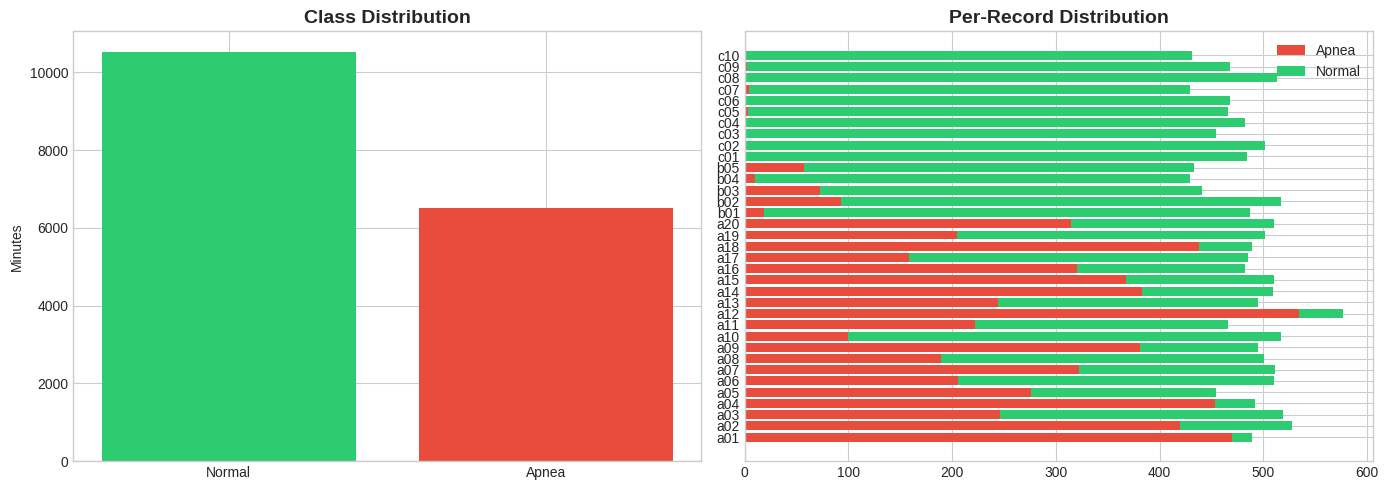

In [19]:
# === CELL 4: Explore Dataset ===
TRAINING_RECORDS = [f'a{i:02d}' for i in range(1, 21)] + \
                   [f'b{i:02d}' for i in range(1, 6)] + \
                   [f'c{i:02d}' for i in range(1, 11)]
TEST_RECORDS = [f'x{i:02d}' for i in range(1, 36)]

total_normal, total_apnea = 0, 0
record_info = []

for rec in TRAINING_RECORDS:
    apn_path = DATA_DIR / f"{rec}.apn"
    if not apn_path.exists():
        continue
    try:
        ann = wfdb.rdann(str(DATA_DIR / rec), 'apn')
        n_normal = sum(1 for s in ann.symbol if s == 'N')
        n_apnea = sum(1 for s in ann.symbol if s == 'A')
        total_normal += n_normal
        total_apnea += n_apnea
        record_info.append({'record': rec, 'normal': n_normal, 'apnea': n_apnea})
    except Exception:
        pass

print(f"\n📊 Training Set Distribution:")
print(f"  Normal minutes: {total_normal}")
print(f"  Apnea minutes:  {total_apnea}")
print(f"  Total:          {total_normal + total_apnea}")
print(f"  Apnea ratio:    {total_apnea/(total_normal+total_apnea)*100:.1f}%")

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(['Normal', 'Apnea'], [total_normal, total_apnea], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Minutes')

df_info = pd.DataFrame(record_info)
axes[1].barh(df_info['record'], df_info['apnea'], color='#e74c3c', label='Apnea')
axes[1].barh(df_info['record'], df_info['normal'], left=df_info['apnea'], color='#2ecc71', label='Normal')
axes[1].set_title('Per-Record Distribution', fontsize=14, fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

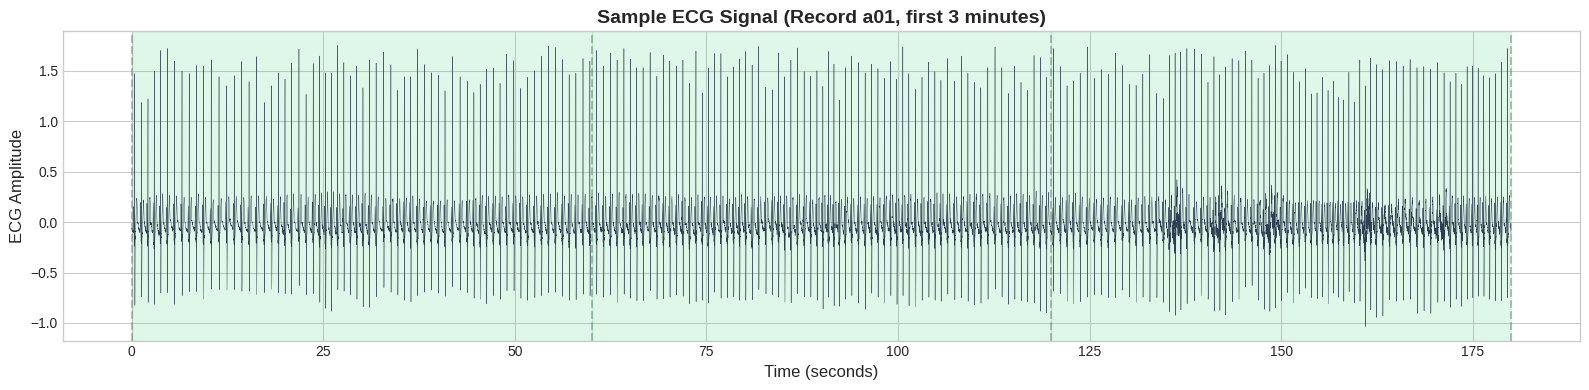

In [20]:
# === CELL 5: Visualize Sample ECG Signal ===
sample_rec = wfdb.rdrecord(str(DATA_DIR / 'a01'), sampfrom=0, sampto=18000)  # 3 minutes
sample_ann = wfdb.rdann(str(DATA_DIR / 'a01'), 'apn')

fig, ax = plt.subplots(figsize=(16, 4))
t = np.arange(len(sample_rec.p_signal)) / 100.0  # seconds
ax.plot(t, sample_rec.p_signal[:, 0], linewidth=0.3, color='#2c3e50')
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('ECG Amplitude', fontsize=12)
ax.set_title('Sample ECG Signal (Record a01, first 3 minutes)', fontsize=14, fontweight='bold')

# Mark minute boundaries
for i in range(4):
    ax.axvline(x=i*60, color='gray', linestyle='--', alpha=0.5)
    if i < 3 and i < len(sample_ann.symbol):
        label = 'Apnea' if sample_ann.symbol[i] == 'A' else 'Normal'
        color = '#e74c3c' if sample_ann.symbol[i] == 'A' else '#2ecc71'
        ax.axvspan(i*60, (i+1)*60, alpha=0.15, color=color, label=label if i == 0 else '')

plt.tight_layout()
plt.savefig('sample_ecg.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Configuration

In [21]:
# === CELL 6: Configuration ===
@dataclass
class Config:
    experiment_name: str = 'apnea_cnn_5fold'
    seed: int = 42
    epochs: int = 50
    learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    optimizer: str = 'adamw'
    scheduler: str = 'cosine'
    warmup_epochs: int = 3
    batch_size: int = 32
    num_workers: int = 2 if IN_COLAB else 0
    mixed_precision: bool = (device.type == 'cuda')
    gradient_accumulation_steps: int = 1
    max_grad_norm: float = 1.0
    label_smoothing: float = 0.0
    n_folds: int = 5
    save_best: bool = True
    save_every: int = 0
    early_stopping: bool = True
    patience: int = 15
    monitor_metric: str = 'val_f1'
    monitor_mode: str = 'max'
    num_classes: int = 2
    output_dir: str = 'experiments'
    # Scalogram params
    img_size: int = 224
    num_scales: int = 64
    sampling_rate: int = 100

cfg = Config()
print("✓ Configuration loaded")
for k, v in asdict(cfg).items():
    print(f"  {k}: {v}")

✓ Configuration loaded
  experiment_name: apnea_cnn_5fold
  seed: 42
  epochs: 50
  learning_rate: 0.0001
  weight_decay: 0.0001
  optimizer: adamw
  scheduler: cosine
  warmup_epochs: 3
  batch_size: 32
  num_workers: 2
  mixed_precision: True
  gradient_accumulation_steps: 1
  max_grad_norm: 1.0
  label_smoothing: 0.0
  n_folds: 5
  save_best: True
  save_every: 0
  early_stopping: True
  patience: 15
  monitor_metric: val_f1
  monitor_mode: max
  num_classes: 2
  output_dir: experiments
  img_size: 224
  num_scales: 64
  sampling_rate: 100


## 4. Dataset & Transforms

In [22]:
# === CELL 7: Reproducibility ===
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.seed)

In [23]:
# === CELL 8: CWT Scalogram Transform ===
class ScalogramTransform:
    """Convert 1D ECG segment to 2D scalogram using CWT."""

    def __init__(self, output_size=(224, 224), num_scales=64, sr=100):
        self.output_size = output_size
        self.num_scales = num_scales
        self.sr = sr
        f_min, f_max = 0.5, 40.0
        center_freq = 0.8
        s_min = center_freq * sr / f_max
        s_max = center_freq * sr / f_min
        self.scales = np.logspace(np.log10(s_min), np.log10(s_max), num_scales)

    def _morlet(self, t, scale, omega0=5.0):
        ts = t / scale
        norm = (np.pi ** -0.25) / np.sqrt(scale)
        return norm * np.exp(1j * omega0 * ts) * np.exp(-0.5 * ts ** 2)

    def _cwt(self, signal):
        n = len(signal)
        out = np.zeros((self.num_scales, n), dtype=np.float32)
        for i, s in enumerate(self.scales):
            wlen = min(int(6 * s), n)
            if wlen % 2 == 0:
                wlen += 1
            t = np.arange(-wlen // 2, wlen // 2 + 1)
            w = self._morlet(t, s)
            out[i] = np.abs(np.convolve(signal, w, mode='same'))
        return out

    def __call__(self, ecg_tensor):
        # ecg_tensor: (1, 6000) or (6000,)
        if isinstance(ecg_tensor, torch.Tensor):
            ecg = ecg_tensor.numpy()
        else:
            ecg = ecg_tensor
        if ecg.ndim == 2:
            ecg = ecg[0]

        # Bandpass filter 0.5-40 Hz
        nyq = self.sr / 2
        b, a = butter(4, [0.5 / nyq, min(40.0 / nyq, 0.99)], btype='band')
        ecg = filtfilt(b, a, ecg).astype(np.float32)

        # Z-score normalize
        mu, sigma = ecg.mean(), ecg.std()
        if sigma > 1e-8:
            ecg = (ecg - mu) / sigma

        # CWT
        scalo = self._cwt(ecg)

        # Min-max normalize
        smin, smax = scalo.min(), scalo.max()
        if smax - smin > 1e-8:
            scalo = (scalo - smin) / (smax - smin)

        # Resize
        h, w = scalo.shape
        th, tw = self.output_size
        scalo = scipy_zoom(scalo, (th / h, tw / w), order=1)

        # Stack to RGB (3 channels)
        scalo = np.stack([scalo, scalo, scalo], axis=0).astype(np.float32)
        return torch.from_numpy(scalo)

transform = ScalogramTransform(output_size=(cfg.img_size, cfg.img_size),
                                num_scales=cfg.num_scales, sr=cfg.sampling_rate)
print("✓ Scalogram transform ready")

✓ Scalogram transform ready


In [24]:
# === CELL 9: Dataset Class ===
SAMPLES_PER_MINUTE = 6000

class ApneaECGDataset(Dataset):
    """Per-minute Apnea-ECG dataset with patient-level 5-fold CV."""

    def __init__(self, data_dir, fold=0, n_folds=5, split='train',
                 transform=None, random_state=42):
        self.data_dir = Path(data_dir)
        self.fold, self.n_folds, self.split = fold, n_folds, split
        self.transform = transform

        train_recs = ([f'a{i:02d}' for i in range(1, 21)] +
                      [f'b{i:02d}' for i in range(1, 6)] +
                      [f'c{i:02d}' for i in range(1, 11)])
        test_recs = [f'x{i:02d}' for i in range(1, 36)]
        records = test_recs if split == 'test' else train_recs

        segs, labels, pids = [], [], []
        for rec in records:
            # CHECK: Skip if record is missing core files (.apn, .hea, .dat)
            if not (self.data_dir / f"{rec}.apn").exists(): continue
            if not (self.data_dir / f"{rec}.hea").exists(): continue
            if not (self.data_dir / f"{rec}.dat").exists(): continue
            
            try:
                ann = wfdb.rdann(str(self.data_dir / rec), 'apn')
                hdr = wfdb.rdheader(str(self.data_dir / rec))
            except Exception:
                continue
            total_min = hdr.sig_len // SAMPLES_PER_MINUTE
            minute_labels = {}
            for si, sym in zip(ann.sample, ann.symbol):
                mi = si // SAMPLES_PER_MINUTE
                if sym in ('A', 'N'):
                    minute_labels[mi] = 1 if sym == 'A' else 0
            for mi in range(total_min):
                if mi in minute_labels:
                    segs.append((rec, mi))
                    labels.append(minute_labels[mi])
                    pids.append(rec)

        self.labels = np.array(labels, dtype=np.int64)

        if split == 'test':
            self.segments, self.patient_ids = segs, pids
        else:
            groups = np.array(pids)
            sgkf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True,
                                         random_state=random_state)
            for fi, (tr_idx, va_idx) in enumerate(sgkf.split(segs, self.labels, groups)):
                if fi == fold:
                    idx = tr_idx if split == 'train' else va_idx
                    break
            self.segments = [segs[i] for i in idx]
            self.labels = self.labels[idx]
            self.patient_ids = [pids[i] for i in idx]

    def __len__(self):
        return len(self.segments)

    def __getitem__(self, idx):
        rec, mi = self.segments[idx]
        label = int(self.labels[idx])
        start = mi * SAMPLES_PER_MINUTE
        record = wfdb.rdrecord(str(self.data_dir / rec),
                               sampfrom=start, sampto=start + SAMPLES_PER_MINUTE)
        sig = record.p_signal.T.astype(np.float32)
        sig = np.nan_to_num(sig, nan=0.0)
        sig = torch.from_numpy(sig)
        if self.transform:
            sig = self.transform(sig)
        return sig, label

    def get_class_weights(self):
        counts = np.bincount(self.labels, minlength=2)
        return torch.FloatTensor(len(self.labels) / (2.0 * counts + 1e-6))

    def get_sample_weights(self):
        counts = np.bincount(self.labels, minlength=2).astype(np.float32)
        w = 1.0 / (counts + 1e-6)
        return torch.from_numpy(w[self.labels])

# Quick test
test_ds = ApneaECGDataset(DATA_DIR, fold=0, split='train', transform=transform)
x, y = test_ds[0]
print(f"✓ Dataset test: input shape={x.shape}, label={y}, dataset size={len(test_ds)}")
del test_ds

✓ Dataset test: input shape=torch.Size([3, 224, 224]), label=0, dataset size=13664


## 5. Model Architecture

In [25]:
# === CELL 10: CNN Model ===
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch))

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x))

class ApneaCNN(nn.Module):
    """ResNet-style CNN for scalogram classification."""
    def __init__(self, num_classes=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1))
        self.layer1 = nn.Sequential(ResidualBlock(64, 64), ResidualBlock(64, 64))
        self.layer2 = nn.Sequential(ResidualBlock(64, 128, stride=2), ResidualBlock(128, 128))
        self.layer3 = nn.Sequential(ResidualBlock(128, 256, stride=2), ResidualBlock(256, 256))
        self.layer4 = nn.Sequential(ResidualBlock(256, 512, stride=2), ResidualBlock(512, 512))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).flatten(1)
        return self.fc(self.dropout(x))

# Test
model = ApneaCNN(num_classes=cfg.num_classes).to(device)
dummy = torch.randn(1, 3, cfg.img_size, cfg.img_size, device=device)
out = model(dummy)
n_params = sum(p.numel() for p in model.parameters())
print(f"✓ Model: ApneaCNN | Params: {n_params:,} | Output: {out.shape}")
del model, dummy, out

✓ Model: ApneaCNN | Params: 11,177,538 | Output: torch.Size([1, 2])


## 6. Metrics & Training Utilities

In [26]:
# === CELL 11: Metrics ===
def compute_metrics(y_true, y_pred, y_prob=None, num_classes=2):
    m = {}
    m['accuracy'] = float(accuracy_score(y_true, y_pred))
    m['f1_macro'] = float(f1_score(y_true, y_pred, average='macro', zero_division=0))
    m['f1_weighted'] = float(f1_score(y_true, y_pred, average='weighted', zero_division=0))
    m['precision'] = float(precision_score(y_true, y_pred, average='macro', zero_division=0))
    m['recall'] = float(recall_score(y_true, y_pred, average='macro', zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    if num_classes == 2 and cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        m['specificity'] = float(tn / (tn + fp + 1e-8))
        m['sensitivity'] = float(tp / (tp + fn + 1e-8))
    if y_prob is not None:
        try:
            m['auc_roc'] = float(roc_auc_score(y_true, y_prob[:, 1]))
        except ValueError:
            m['auc_roc'] = 0.0
    else:
        m['auc_roc'] = 0.0
    m['confusion_matrix'] = cm.tolist()
    return m

In [27]:
# === CELL 12: FLOPs Counter ===
def count_flops(model, input_shape, dev):
    info = {'total_params': sum(p.numel() for p in model.parameters()),
            'trainable_params': sum(p.numel() for p in model.parameters() if p.requires_grad),
            'flops': 0, 'macs': 0}
    try:
        from fvcore.nn import FlopCountAnalysis
        dummy = torch.randn(input_shape, device=dev)
        info['flops'] = int(FlopCountAnalysis(model, dummy).total())
        info['macs'] = info['flops'] // 2
    except Exception:
        try:
            from thop import profile
            dummy = torch.randn(input_shape, device=dev)
            macs, _ = profile(model, inputs=(dummy,), verbose=False)
            info['macs'], info['flops'] = int(macs), int(macs * 2)
        except Exception:
            pass
    return info

## 7. Five-Fold Cross-Validation Training

In [28]:
# === CELL 13: Training Loop ===
def train_one_fold(fold, cfg, transform):
    """Train a single fold and return metrics."""
    seed_everything(cfg.seed + fold)

    # Data
    train_ds = ApneaECGDataset(DATA_DIR, fold=fold, n_folds=cfg.n_folds,
                                split='train', transform=transform, random_state=cfg.seed)
    val_ds = ApneaECGDataset(DATA_DIR, fold=fold, n_folds=cfg.n_folds,
                              split='val', transform=transform, random_state=cfg.seed)

    sampler = WeightedRandomSampler(train_ds.get_sample_weights(), len(train_ds))
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, sampler=sampler,
                               num_workers=cfg.num_workers, pin_memory=(device.type == 'cuda'))
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                             num_workers=cfg.num_workers, pin_memory=(device.type == 'cuda'))

    print(f"\n{'='*60}\n  FOLD {fold} | Train: {len(train_ds)} | Val: {len(val_ds)}\n{'='*60}")

    # Model
    model = ApneaCNN(num_classes=cfg.num_classes).to(device)

    # FLOPs (only fold 0)
    if fold == 0:
        fi = count_flops(model, (1, 3, cfg.img_size, cfg.img_size), device)
        print(f"  Params: {fi['total_params']:,} | FLOPs: {fi['flops']:,} | MACs: {fi['macs']:,}")

    # Loss, optimizer, scheduler
    class_w = train_ds.get_class_weights().to(device)
    criterion = nn.CrossEntropyLoss(weight=class_w)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(cfg.epochs - cfg.warmup_epochs, 1))
    scaler = GradScaler() if cfg.mixed_precision else None

    # Tracking
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
               'val_f1': [], 'val_auc': [], 'lr': []}
    best_f1, patience_ctr, best_state = -1, 0, None
    fold_dir = Path(cfg.output_dir) / cfg.experiment_name / f'fold_{fold}'
    fold_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(cfg.epochs):
        t0 = time.time()

        # --- Train ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for step, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            # Warmup LR
            if epoch < cfg.warmup_epochs:
                warmup_steps = cfg.warmup_epochs * len(train_loader)
                cur = epoch * len(train_loader) + step
                for pg in optimizer.param_groups:
                    pg['lr'] = cfg.learning_rate * min(1.0, cur / max(warmup_steps, 1))

            if scaler:
                with autocast():
                    out = model(inputs)
                    loss = criterion(out, targets)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
                scaler.step(optimizer)
                scaler.update()
            else:
                out = model(inputs)
                loss = criterion(out, targets)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
                optimizer.step()
            optimizer.zero_grad()

            running_loss += loss.item()
            _, preds = out.max(1)
            total += targets.size(0)
            correct += preds.eq(targets).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100.0 * correct / total

        # --- Validate ---
        model.eval()
        val_loss_sum = 0.0
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                out = model(inputs)
                val_loss_sum += criterion(out, targets).item()
                probs = torch.softmax(out, dim=1)
                _, preds = out.max(1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(targets.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        val_loss = val_loss_sum / max(len(val_loader), 1)
        vm = compute_metrics(np.array(all_labels), np.array(all_preds),
                              np.array(all_probs), cfg.num_classes)

        # Scheduler
        lr = optimizer.param_groups[0]['lr']
        if epoch >= cfg.warmup_epochs and scheduler:
            scheduler.step()

        # Log
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(vm['accuracy'] * 100)
        history['val_f1'].append(vm['f1_macro'])
        history['val_auc'].append(vm['auc_roc'])
        history['lr'].append(lr)

        elapsed = time.time() - t0
        print(f"  Ep {epoch+1:3d}/{cfg.epochs} | "
              f"TrL: {train_loss:.4f} TrA: {train_acc:.1f}% | "
              f"VaL: {val_loss:.4f} VaA: {vm['accuracy']*100:.1f}% "
              f"F1: {vm['f1_macro']:.4f} AUC: {vm['auc_roc']:.4f} | "
              f"LR: {lr:.2e} | {elapsed:.1f}s")

        # Early stopping & checkpointing
        if vm['f1_macro'] > best_f1:
            best_f1 = vm['f1_macro']
            patience_ctr = 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save({'model_state_dict': best_state, 'epoch': epoch,
                         'best_f1': best_f1, 'config': asdict(cfg)},
                        fold_dir / 'best_model.pt')
            print(f"    ✓ Best F1={best_f1:.4f} saved")
        else:
            patience_ctr += 1

        if cfg.early_stopping and patience_ctr >= cfg.patience:
            print(f"  ✗ Early stopping at epoch {epoch+1}")
            break

    # Restore best & final eval
    if best_state:
        model.load_state_dict(best_state)
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            out = model(inputs)
            probs = torch.softmax(out, dim=1)
            _, preds = out.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    final_metrics = compute_metrics(np.array(all_labels), np.array(all_preds),
                                     np.array(all_probs), cfg.num_classes)
    final_metrics['history'] = history
    final_metrics['y_true'] = all_labels
    final_metrics['y_prob'] = [p[1] for p in all_probs]

    # Save history CSV
    pd.DataFrame(history).to_csv(fold_dir / 'history.csv', index=False)

    return final_metrics

In [ ]:
# === CELL 14: Run All Folds ===
print("\n" + "🚀" * 20)
print("  STARTING 5-FOLD CROSS-VALIDATION")
print("🚀" * 20)

all_fold_results = []
for fold in range(cfg.n_folds):
    result = train_one_fold(fold, cfg, transform)
    all_fold_results.append(result)
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()


🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
  STARTING 5-FOLD CROSS-VALIDATION
🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀

  FOLD 0 | Train: 13664 | Val: 3359
  Params: 11,177,538 | FLOPs: 0 | MACs: 0
  Ep   1/50 | TrL: 0.4733 TrA: 74.7% | VaL: 3.0071 VaA: 36.2% F1: 0.3037 AUC: 0.7637 | LR: 3.33e-05 | 827.4s
    ✓ Best F1=0.3037 saved
  Ep   2/50 | TrL: 0.3139 TrA: 85.6% | VaL: 1.0812 VaA: 56.0% F1: 0.5567 AUC: 0.8362 | LR: 6.66e-05 | 842.8s
    ✓ Best F1=0.5567 saved


## 8. Results Aggregation & Visualization

In [ ]:
# === CELL 15: Aggregate Results ===
metric_keys = ['accuracy', 'f1_macro', 'f1_weighted', 'precision', 'recall',
               'specificity', 'sensitivity', 'auc_roc']

print("\n" + "=" * 70)
print("  5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)
print(f"  {'Metric':<20s} {'Mean':>10s} {'± Std':>10s}  Per-fold")
print("  " + "-" * 64)

summary_data = {}
for key in metric_keys:
    vals = [r[key] for r in all_fold_results]
    mean, std = np.mean(vals), np.std(vals)
    summary_data[key] = {'mean': mean, 'std': std, 'values': vals}
    per_fold = ", ".join(f"{v:.4f}" for v in vals)
    print(f"  {key:<20s} {mean:>10.4f} {std:>10.4f}  [{per_fold}]")

# FLOPs info
model_tmp = ApneaCNN(num_classes=cfg.num_classes).to(device)
fi = count_flops(model_tmp, (1, 3, cfg.img_size, cfg.img_size), device)
print("  " + "-" * 64)
print(f"  FLOPs: {fi['flops']:,}  |  Params: {fi['total_params']:,}  |  MACs: {fi['macs']:,}")
print("=" * 70)
del model_tmp

# Save summary JSON
results_dir = Path(cfg.output_dir) / cfg.experiment_name
results_dir.mkdir(parents=True, exist_ok=True)
with open(results_dir / 'summary.json', 'w') as f:
    json.dump({'config': asdict(cfg), 'flops': fi, 'results': summary_data},
              f, indent=2, default=str)
print(f"\n✓ Summary saved to {results_dir / 'summary.json'}")

In [ ]:
# === CELL 16: Training Curves ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for fold, res in enumerate(all_fold_results):
    h = res['history']
    axes[0, 0].plot(h['train_loss'], alpha=0.7, label=f'Fold {fold}')
    axes[0, 1].plot(h['val_loss'], alpha=0.7, label=f'Fold {fold}')
    axes[0, 2].plot(h['train_acc'], alpha=0.7, label=f'Fold {fold}')
    axes[1, 0].plot(h['val_acc'], alpha=0.7, label=f'Fold {fold}')
    axes[1, 1].plot(h['val_f1'], alpha=0.7, label=f'Fold {fold}')
    axes[1, 2].plot(h['val_auc'], alpha=0.7, label=f'Fold {fold}')

titles = ['Train Loss', 'Val Loss', 'Train Acc (%)', 'Val Acc (%)', 'Val F1 (Macro)', 'Val AUC-ROC']
for ax, title in zip(axes.flat, titles):
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves Across 5 Folds', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(results_dir / 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# === CELL 17: Confusion Matrices ===
fig, axes = plt.subplots(1, cfg.n_folds, figsize=(4 * cfg.n_folds, 4))
if cfg.n_folds == 1:
    axes = [axes]

for fold, (ax, res) in enumerate(zip(axes, all_fold_results)):
    cm = np.array(res['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Apnea'], yticklabels=['Normal', 'Apnea'])
    ax.set_title(f'Fold {fold}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(results_dir / 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# === CELL 18: ROC Curves ===
fig, ax = plt.subplots(figsize=(8, 7))
mean_fpr = np.linspace(0, 1, 100)
all_tprs = []

for fold, res in enumerate(all_fold_results):
    fpr, tpr, _ = roc_curve(res['y_true'], res['y_prob'])
    auc_val = roc_auc_score(res['y_true'], res['y_prob'])
    ax.plot(fpr, tpr, alpha=0.4, label=f'Fold {fold} (AUC={auc_val:.3f})')
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    all_tprs.append(interp_tpr)

mean_tpr = np.mean(all_tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean([roc_auc_score(r['y_true'], r['y_prob']) for r in all_fold_results])
std_auc = np.std([roc_auc_score(r['y_true'], r['y_prob']) for r in all_fold_results])
ax.plot(mean_fpr, mean_tpr, 'b-', linewidth=2.5,
        label=f'Mean ROC (AUC={mean_auc:.3f} ± {std_auc:.3f})')
ax.fill_between(mean_fpr, np.max([mean_tpr - np.std(all_tprs, axis=0), np.zeros_like(mean_tpr)], axis=0),
                np.min([mean_tpr + np.std(all_tprs, axis=0), np.ones_like(mean_tpr)], axis=0),
                alpha=0.15, color='blue')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves (5-Fold CV)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(str(results_dir / 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# === CELL 19: Paper-Ready Results Table ===
print("\n📄 LaTeX-Ready Results Table:")
print(r"\begin{table}[h]")
print(r"\centering")
print(r"\caption{5-Fold Cross-Validation Results for Sleep Apnea Detection}")
print(r"\begin{tabular}{lcc}")
print(r"\hline")
print(r"Metric & Mean & Std \\")
print(r"\hline")
for key in metric_keys:
    m, s = summary_data[key]['mean'], summary_data[key]['std']
    nice_name = key.replace('_', ' ').title()
    print(f"{nice_name} & {m:.4f} & $\\pm${s:.4f} \\\\")
print(r"\hline")
print(f"FLOPs & \\multicolumn{{2}}{{c}}{{{fi['flops']:,}}} \\\\")
print(f"Parameters & \\multicolumn{{2}}{{c}}{{{fi['total_params']:,}}} \\\\")
print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table}")

print("\n✅ Experiment complete! All results saved to:", results_dir)